# Activiteit & Planning

**Thema:** De dynamiek van de agenda en vergaderzalen.

**Kernvragen:** Hoe vaak wordt er vergaderd, welke zalen zijn het populairst, hoe vaak worden activiteiten verplaatst of geannuleerd, en wat is de verdeling tussen openbare en besloten activiteiten?

Dit notebook verkent o.a. de silver-tabellen `activiteit`, `vergadering`, `zaal`, `reservering` en `activiteit_vervangen_vanuit`.

In [43]:
# Importeer Path om met mappen en bestandspaden te werken
from pathlib import Path

# Importeer DuckDB voor de databaseverbinding
import duckdb

# Importeer Pandas voor tabellen en data-analyse
import pandas as pd

# Importeer Matplotlib voor grafieken
import matplotlib.pyplot as plt


# Zoek automatisch naar het databasebestand tweedekamer.duckdb
def find_database(start: Path | None = None) -> Path:
    
    # Begin in de huidige map
    current = (start or Path.cwd()).resolve()
    
    # Kijk in de huidige map en bovenliggende mappen
    for folder in (current, *current.parents):
        
        # Maak het verwachte pad naar het databasebestand
        candidate = folder / "tweedekamer.duckdb"
        
        # Controleer of het bestand bestaat
        if candidate.is_file():
            return candidate
    
    # Geef een foutmelding als de database niet gevonden wordt
    raise FileNotFoundError("Could not find tweedekamer.duckdb from the current directory")


# Zoek het databasebestand
database_path = find_database()

# Maak een alleen-lezen verbinding met de DuckDB-database
connection = duckdb.connect(str(database_path), read_only=True)


# Functie om een SQL-query uit te voeren en het resultaat als Pandas DataFrame terug te geven
def query_df(sql: str, parameters=None) -> pd.DataFrame:
    return connection.execute(sql, parameters or []).fetchdf()


# Laat zien waar het databasebestand gevonden is
database_path

PosixPath('/Users/etiennelieffering/tweedekamer-monitor/tweedekamer.duckdb')

## Onderwerp 1

In dit onderdeel onderzoek ik hoe vaak er wordt vergaderd en welke vergaderzalen het meest worden gebruikt.

In [44]:
# Haal per zaal het aantal vergaderingen op
vergaderzalen = query_df("""
SELECT
    zaal,                              -- Naam van de zaal
    COUNT(*) AS aantal_vergaderingen  -- Tel het aantal vergaderingen
FROM silver.vergadering
WHERE zaal IS NOT NULL                 -- Negeer lege zaalnamen
GROUP BY zaal                          -- Groepeer per zaal
ORDER BY aantal_vergaderingen DESC     -- Hoogste aantal bovenaan
LIMIT 20                               -- Alleen de top 20
""")

# Laat het resultaat als tabel zien
vergaderzalen

,zaal,aantal_vergaderingen
0,Plenaire zaal,1409
1,Thorbeckezaal,1370
2,Groen van Prinstererzaal,1246
3,Troelstrazaal,1121
4,Suze Groenewegzaal,559
5,Wttewaall van Stoetwegenzaal,481
6,Klompezaal,295
7,Klompézaal,237
8,Aletta Jacobszaal,157
9,Tilanuskamer,123


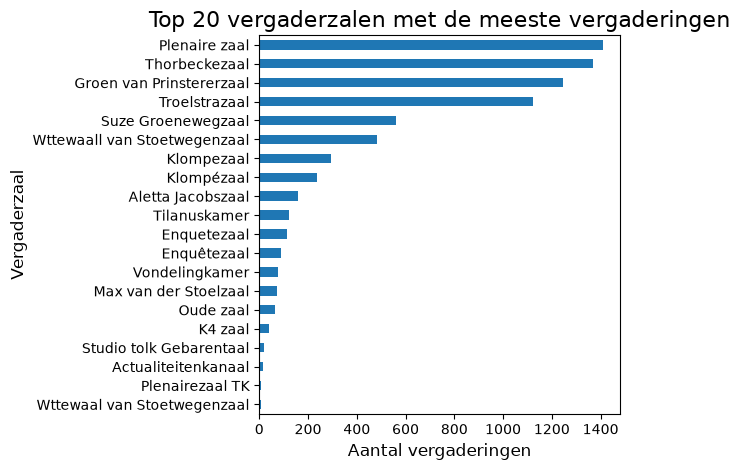

In [45]:
# Maak een horizontale staafgrafiek van het aantal vergaderingen per zaal
vergaderzalen.plot.barh(
    x="zaal",                    # Zaalnamen op de y-as
    y="aantal_vergaderingen",    # Aantal vergaderingen op de x-as
    legend=False                 # Geen legenda nodig
)

# Geef de grafiek een titel
plt.title("Top 20 vergaderzalen met de meeste vergaderingen", fontsize=16)

# Geef de assen duidelijke namen
plt.xlabel("Aantal vergaderingen", fontsize=12)
plt.ylabel("Vergaderzaal", fontsize=12)

# Zet de zaal met de meeste vergaderingen bovenaan
plt.gca().invert_yaxis()

# Zorg dat alles netjes binnen de grafiek past
plt.tight_layout()

# Toon de grafiek
plt.show()

Conclusie: De Plenaire zaal wordt het vaakst gebruikt, gevolgd door de Thorbeckezaal, Groen van Prinstererzaal en de Troelstrazaal. Deze zalen worden duidelijk vaker gebruikt dan de overige zalen.
Daarnaast valt op dat sommige zaalnamen mogelijk dubbel voorkomen door verschillende schrijfwijzen. Voorbeelden hiervan zijn Klompzaal en Klompézaal en Enquetezaal en Enquêtezaal. Dit kan invloed hebben op de tellingen en is daarom een aandachtspunt voor de datakwaliteit.

## Onderwerp 2
Opschonen dubbele zaalnamen

In de data komen enkele zaalnamen meerdere keren voor met een iets andere schrijfwijze, zoals Klompzaal en Klompézaal. Waarschijnlijk gaat het hier om dezelfde zaal. Daarom worden deze namen in de volgende analyse samengevoegd, zodat de tellingen beter vergelijkbaar zijn.

In [46]:
# Importeer hulpmiddel om accenten uit tekst te kunnen halen
import unicodedata

# Maak een kopie van de oorspronkelijke tabel
vergaderzalen_schoon = vergaderzalen.copy()


# Functie om zaalnamen te normaliseren
def maak_sleutel(naam):
    # Zet tekst om naar kleine letters en verwijder accenten
    naam = unicodedata.normalize("NFKD", naam).casefold()

    # Verwijder spaties en andere tekens; alleen letters/cijfers blijven over
    naam = "".join(teken for teken in naam if teken.isalnum())

    return naam


# Maak voor elke zaalnaam een gestandaardiseerde sleutel
vergaderzalen_schoon["zaal_sleutel"] = (
    vergaderzalen_schoon["zaal"].apply(maak_sleutel)
)


# Voeg bekende verschillende schrijfwijzen van dezelfde zaal samen
vergaderzalen_schoon["zaal_sleutel"] = (
    vergaderzalen_schoon["zaal_sleutel"].replace({
        "klompzaal": "klompezaal",
        "wttewaallvanstoetwegenzaal": "wttewaalvanstoetwegenzaal"
    })
)


# Tel de vergaderingen opnieuw op per opgeschoonde zaalnaam
vergaderzalen_schoon = (
    vergaderzalen_schoon
    .groupby("zaal_sleutel", as_index=False)["aantal_vergaderingen"]
    .sum()
    .sort_values("aantal_vergaderingen", ascending=False)
)


# Zet de opgeschoonde sleutels weer om naar nette zaalnamen
vergaderzalen_schoon["zaal"] = vergaderzalen_schoon["zaal_sleutel"].replace({
    "plenairezaal": "Plenaire zaal",
    "thorbeckezaal": "Thorbeckezaal",
    "groenvanprinstererzaal": "Groen van Prinstererzaal",
    "troelstrazaal": "Troelstrazaal",
    "suzegroenewegzaal": "Suze Groenewegzaal",
    "wttewaalvanstoetwegenzaal": "Wttewaal van Stoetwegenzaal",
    "klompezaal": "Klompézaal",
    "enquetezaal": "Enquêtezaal",
    "alettajacobszaal": "Aletta Jacobszaal",
    "tilanuskamer": "Tilanuskamer",
    "vondelingkamer": "Vondelingkamer",
    "maxvanderstoelzaal": "Max van der Stoelzaal",
    "oudezaal": "Oude zaal",
    "k4zaal": "K4 zaal",
    "studiotolkgeberentaal": "Studio tolk Gebarentaal",
    "activiteitenkanaal": "Activiteitenkanaal",
    "plenairezaaltk": "Plenairezaal TK"
})


# Laat alleen de zaalnaam en het aantal vergaderingen zien
vergaderzalen_schoon[["zaal", "aantal_vergaderingen"]]

,zaal,aantal_vergaderingen
8,Plenaire zaal,1409
12,Thorbeckezaal,1370
3,Groen van Prinstererzaal,1246
14,Troelstrazaal,1121
11,Suze Groenewegzaal,559
5,Klompézaal,532
16,Wttewaal van Stoetwegenzaal,490
2,Enquêtezaal,201
1,Aletta Jacobszaal,157
13,Tilanuskamer,123


<Figure size 1400x800 with 0 Axes>

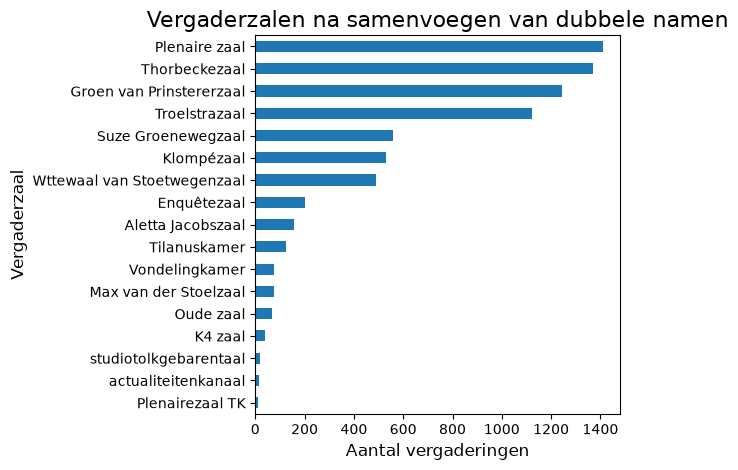

In [47]:
# Maak de grafiek groter
plt.figure(figsize=(14, 8))

# Maak een horizontale staafgrafiek van de opgeschoonde zaalnamen
vergaderzalen_schoon.plot.barh(
    x="zaal",                    # Zaalnamen
    y="aantal_vergaderingen",    # Aantal vergaderingen per zaal
    legend=False                 # Geen legenda tonen
)

# Geef de grafiek een titel
plt.title("Vergaderzalen na samenvoegen van dubbele namen", fontsize=16)

# Geef de assen duidelijke namen
plt.xlabel("Aantal vergaderingen", fontsize=12)
plt.ylabel("Vergaderzaal", fontsize=12)

# Zet de zaal met de meeste vergaderingen bovenaan
plt.gca().invert_yaxis()

# Zorg dat alles netjes binnen de figuur past
plt.tight_layout()

# Toon de grafiek
plt.show()

Conclusie: Na het opschonen van de zaalnamen zijn verschillende schrijfwijzen samengevoegd. Hierdoor stijgt het aantal vergaderingen voor de Klompézaal naar 532, de Wttewaal van Stoetwegenzaal naar 490 en de Enquêtezaal naar 201. Dit geeft een betrouwbaarder beeld van het daadwerkelijke gebruik van de vergaderzalen.

## onderwerp 3
Vervangingsrelatie per jaar

In [48]:
# Bekijk de eerste 20 vervangingsrelaties
query_df("""
SELECT *
FROM silver.activiteit_vervangen_vanuit
LIMIT 20
""")

,activiteit_id,vervangen_vanuit_id,relatie_gewijzigd_op
0,9da7ba43-a005-4235-9156-5184aea40461,a34ba856-50a9-488b-a119-b710340b5fd7,2024-08-19 11:11:20.972232+02:00
1,165d19e0-beb5-4eba-9ce8-30aa1790d5ea,a39b08cc-48a1-4783-9f9a-8d6ba508c566,2026-09-10 07:47:54.919498+02:00
2,361f20ef-4d22-47e1-b4e7-3634e3e373b3,a431c76e-3470-4a6d-820e-54e778b393f8,2024-02-19 11:01:39.210635+01:00
3,996bd042-2d16-4707-b327-7c2a058e4671,a445a6a7-2d80-4bca-b24f-5eb24c279923,2024-02-19 12:30:17.923486+01:00
4,1845f431-1bad-4535-8491-3643cb49f7fb,a4a46079-c908-4b21-b21b-021597e854ad,2024-08-09 13:16:42.917212+02:00
5,2d2f73f3-7f02-4281-b042-644cb807cbfa,a56837d8-d9c6-4e2f-be93-94aff8a75b7f,2026-07-26 12:44:44.172400+02:00
6,67149682-f979-452a-ae66-1e1d1abe9483,a64ac303-e4a6-4b72-873b-3bc962e5ba4d,2026-09-10 15:45:08.841378+02:00
7,2672988d-cec8-4fa6-8b7f-af40e32ccd29,a6c13b34-6e7f-4ec2-9670-8062286217a7,2024-02-19 13:02:13.268163+01:00
8,969c8a8b-97d5-48ca-be4f-ef903436a720,a7339334-18c3-4184-b9aa-f4bd9097e5d1,2026-09-10 07:49:21.081555+02:00
9,e0cb8034-846f-4f30-9c6a-fd53b0ea7f44,a8e07994-2f95-4417-838c-b395f2093c0a,2026-07-27 05:07:36.466889+02:00


In [49]:
# Tel per jaar hoeveel vervangingsrelaties er zijn geregistreerd
vervangingen_per_jaar = query_df("""
SELECT
    YEAR(relatie_gewijzigd_op) AS jaar,          -- Haal het jaar uit de datum
    COUNT(*) AS aantal_vervangingen              -- Tel het aantal vervangingsrelaties
FROM silver.activiteit_vervangen_vanuit
GROUP BY jaar                                    -- Groepeer per jaar
ORDER BY jaar                                    -- Zet de jaren op volgorde
""")

# Laat het resultaat als tabel zien
vervangingen_per_jaar

,jaar,aantal_vervangingen
0,2024,2980
1,2025,218
2,2026,2696


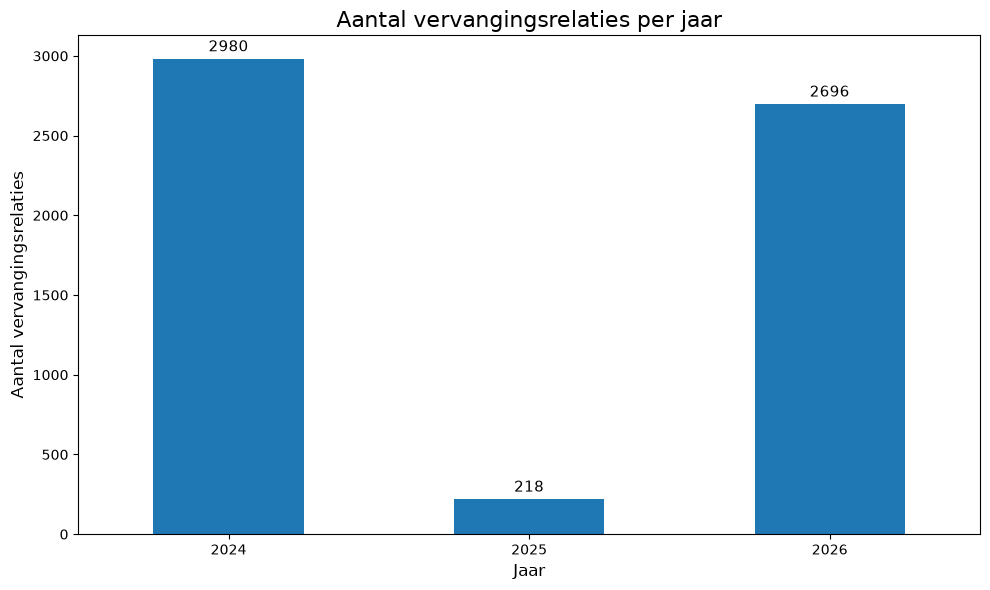

In [50]:
# Maak een staafgrafiek van het aantal vervangingsrelaties per jaar
ax = vervangingen_per_jaar.plot.bar(
    x="jaar",                     # Jaar op de x-as
    y="aantal_vervangingen",      # Aantal vervangingsrelaties op de y-as
    figsize=(10, 6),              # Grootte van de grafiek
    legend=False                  # Geen legenda tonen
)

# Geef de grafiek een titel
plt.title("Aantal vervangingsrelaties per jaar", fontsize=16)

# Geef de assen duidelijke namen
plt.xlabel("Jaar", fontsize=12)
plt.ylabel("Aantal vervangingsrelaties", fontsize=12)

# Zorg dat de jaartallen recht staan
plt.xticks(rotation=0)

# Zet het aantal boven elke balk
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=11)

# Zorg dat alles netjes binnen de figuur past
plt.tight_layout()

# Toon de grafiek
plt.show()

Conclusie: Deze tabel laat zien wanneer een activiteit een eerdere activiteit vervangt. Dit kan bijvoorbeeld gebeuren bij een wijziging of verplaatsing. Uit deze tabel alleen is niet direct af te leiden of een activiteit daadwerkelijk is geannuleerd. In 2024 en 2026 zijn veel meer vervangingsrelaties geregistreerd dan in 2025. In 2024 zijn dit 2980 relaties en in 2026 2696, tegenover slechts 218 in 2025. Het lage aantal in 2025 valt sterk op en kan mogelijk wijzen op een verschil in registratie of onvolledige data. Daarom moet voorzichtig worden geconcludeerd dat er in 2025 daadwerkelijk veel minder activiteiten zijn vervangen.

## Onderwerp 4
Wat is de verdeling tussen openbare en besloten activiteiten?

In dit onderdeel onderzoek ik wat de verdeling is tussen openbare en besloten activiteiten.

In [51]:
# Bekijk de eerste 5 activiteiten om te zien welke kolommen beschikbaar zijn
query_df("""
SELECT *
FROM silver.activiteit
LIMIT 5
""")

,id,soort,nummer,onderwerp,datum_soort,datum,aanvangstijd,eindtijd,locatie,besloten,...,voortouwkortenaam,voortouwcommissie_id,aanvraagdatum,datum_verzoek_eerste_verlenging,datum_mededeling_eerste_verlenging,datum_verzoek_tweede_verlenging,datum_mededeling_tweede_verlenging,vervaldatum,gewijzigd_op,api_gewijzigd_op
0,a335f187-7a61-4ff1-9ecc-49b8333a8df6,Procedurevergadering,2015A05109,Procedurevergadering,Dag,2016-03-02,2016-03-02 14:00:00,2016-03-02 14:30:00,NaN,False,...,KR,af1f56ee-1f1f-4bed-b0ab-31097ecdddef,NaT,NaT,NaT,NaT,NaT,NaT,2024-02-19 11:55:25.387000+01:00,2024-02-19 13:24:15.236883+01:00
1,a345c10d-a8a3-49dc-a612-0afe08c6b2fd,Algemeen overleg,2011A01966,Vreemdelingen- en Asielbeleid,Dag,2011-06-08,2011-06-08 16:30:00,2011-06-08 18:30:00,NaN,False,...,x - I&A (2010-2012),86cce16c-39ef-46bd-8fbe-4db6a57f433e,NaT,NaT,NaT,NaT,NaT,NaT,2024-08-19 13:08:42.123000+02:00,2024-08-19 11:10:12.799162+02:00
2,a34ba856-50a9-488b-a119-b710340b5fd7,Algemeen overleg,2018A00687,Voortgangsrapportage Nationaal Techniekpact 20...,Dag,2018-04-24,2018-04-24 20:30:00,2018-04-24 23:30:00,NaN,False,...,x - EZK (2017-2024),e1983fd8-9393-4814-8751-50f0d802a512,NaT,NaT,NaT,NaT,NaT,NaT,2024-08-19 13:08:45.540000+02:00,2024-08-19 11:11:22.769154+02:00
3,a36a7c3c-ee8e-4c0d-a1bf-0d97d1917336,Vergadering,2015A00077,Voorbereiding RTG/hoorzitting Integratie,Dag,2015-01-21,2015-01-21 18:30:00,2015-01-21 19:30:00,NaN,True,...,SZW,b18e6abf-15b8-445f-a177-e1823ee63424,NaT,NaT,NaT,NaT,NaT,NaT,2024-02-19 11:55:25.387000+01:00,2024-02-19 11:13:23.889695+01:00
4,a38f0474-b5d7-43c5-b6d8-81a8eee0917c,Werkbezoek,2013A00667,Kennismakingsbezoek/rondleiding ministerie BZK,Dag,2013-04-23,2013-04-23 18:30:00,2013-04-23 20:00:00,Ministerie BZK,True,...,BiZa,177eb895-6307-4268-94f6-a0f80dc3e358,NaT,NaT,NaT,NaT,NaT,NaT,2024-02-19 11:55:25.387000+01:00,2024-02-19 12:17:06.502096+01:00


In [52]:
# Tel hoeveel activiteiten openbaar, besloten of onbekend zijn
openbaar_besloten = query_df("""
SELECT
    CASE
        WHEN besloten = TRUE THEN 'Besloten'      -- True betekent besloten
        WHEN besloten = FALSE THEN 'Openbaar'     -- False betekent openbaar
        ELSE 'Onbekend'                           -- Voor lege/onbekende waarden
    END AS type_activiteit,
    COUNT(*) AS aantal                            -- Tel het aantal activiteiten
FROM silver.activiteit
GROUP BY type_activiteit                          -- Groepeer per type
ORDER BY aantal DESC                              -- Grootste aantal bovenaan
""")

# Laat de aantallen als tabel zien
openbaar_besloten

,type_activiteit,aantal
0,Openbaar,46652
1,Besloten,26591


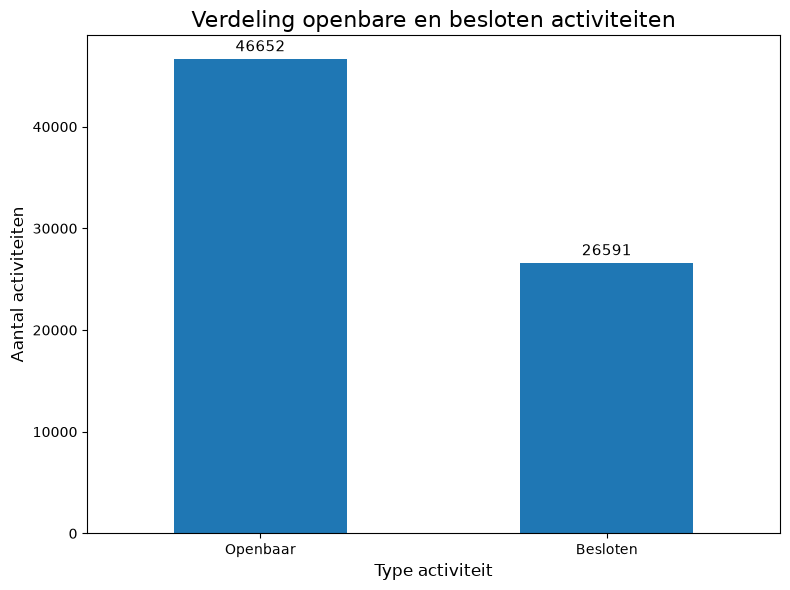

In [53]:
# Maak een staafgrafiek van het aantal openbare en besloten activiteiten
ax = openbaar_besloten.plot.bar(
    x="type_activiteit",
    y="aantal",
    figsize=(8, 6),
    legend=False
)

# Geef de grafiek een titel
plt.title("Verdeling openbare en besloten activiteiten", fontsize=16)

# Geef de assen duidelijke namen
plt.xlabel("Type activiteit", fontsize=12)
plt.ylabel("Aantal activiteiten", fontsize=12)

# Zet de labels recht
plt.xticks(rotation=0)

# Zet het aantal boven elke balk
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=11)

# Zorg dat alles netjes binnen de grafiek past
plt.tight_layout()

# Toon de grafiek
plt.show()

Conclusie: In de dataset komen meer openbare dan besloten activiteiten voor. Er zijn 46.652 openbare activiteiten en 26.591 besloten activiteiten geregistreerd. Daarmee is het grootste deel van de activiteiten openbaar.

## Controle

In [54]:
# Controleer hoeveel vergaderingen er totaal zijn en hoeveel een zaal hebben
query_df("""
SELECT
    COUNT(*) AS totaal_vergaderingen,              -- Totaal aantal vergaderingen
    COUNT(zaal) AS vergaderingen_met_zaal,         -- Vergaderingen met ingevulde zaal
    COUNT(*) - COUNT(zaal) AS vergaderingen_zonder_zaal  -- Vergaderingen zonder zaal
FROM silver.vergadering
""")

,totaal_vergaderingen,vergaderingen_met_zaal,vergaderingen_zonder_zaal
0,7507,7507,0


Alle 7.507 vergaderingen hebben een zaal ingevuld. Er zijn dus geen ontbrekende zaalwaarden in deze tabel.